# Q2: Unsupervised Learning — Customer Segmentation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
try:
    df2 = pd.read_csv('../data/q2_customers.csv')
except Exception:
    df2 = pd.read_csv('q2_customers.csv')
print('Loaded customers dataset. Shape:', df2.shape)

Loaded customers dataset. Shape: (500, 6)


In [2]:
# Data Inspection
print('Columns:', df2.columns.tolist())
print()
print('Description:')
print(df2.describe())

Columns: ['age', 'annual_spend', 'visits_per_month', 'basket_size', 'days_since_last_visit', 'num_categories_purchased']

Description:
             age   annual_spend  visits_per_month  basket_size  \
count  500.00000     500.000000        500.000000   500.000000   
mean    40.45200   48856.948000          8.414000  2682.286000   
std     14.42664   32856.795353          5.324595  2274.957339   
min     18.00000    5038.000000          1.000000   212.000000   
25%     28.00000   19213.250000          4.000000   727.750000   
50%     41.00000   44257.000000          8.000000  2051.500000   
75%     50.00000   75373.000000         12.000000  4223.750000   
max     69.00000  119757.000000         19.000000  7981.000000   

       days_since_last_visit  num_categories_purchased  
count             500.000000                500.000000  
mean               49.466000                  4.658000  
std                49.699143                  2.438222  
min                 0.000000              

## Exploratory Data Analysis

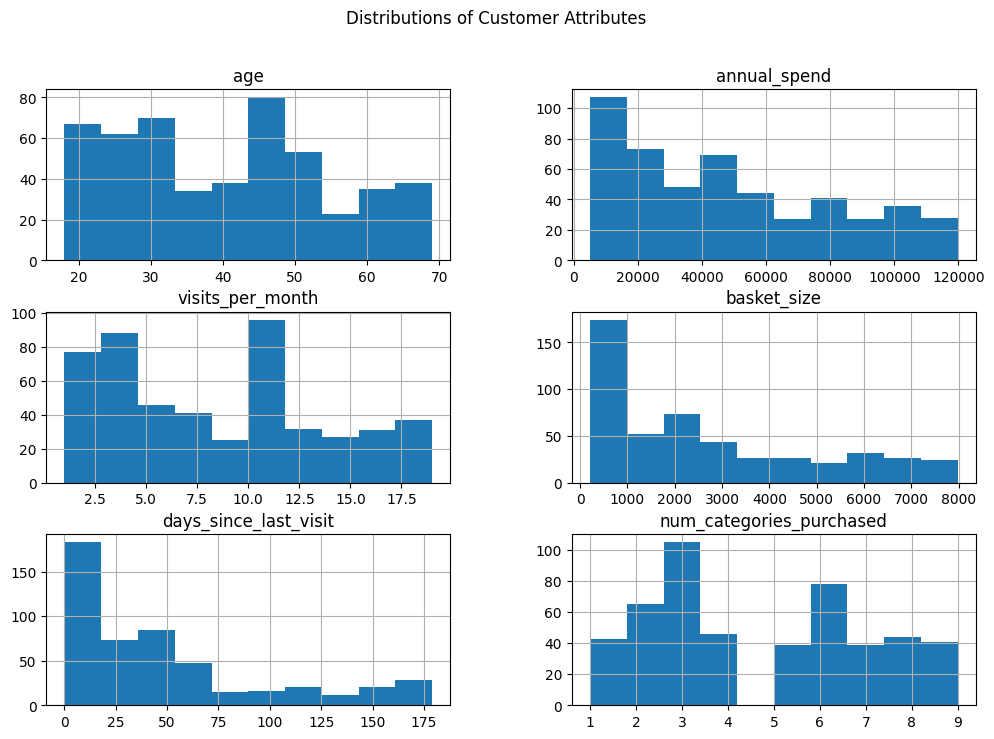

In [3]:
# Histograms for each variable
df2.hist(figsize=(12,8))
plt.suptitle('Distributions of Customer Attributes')
plt.show()

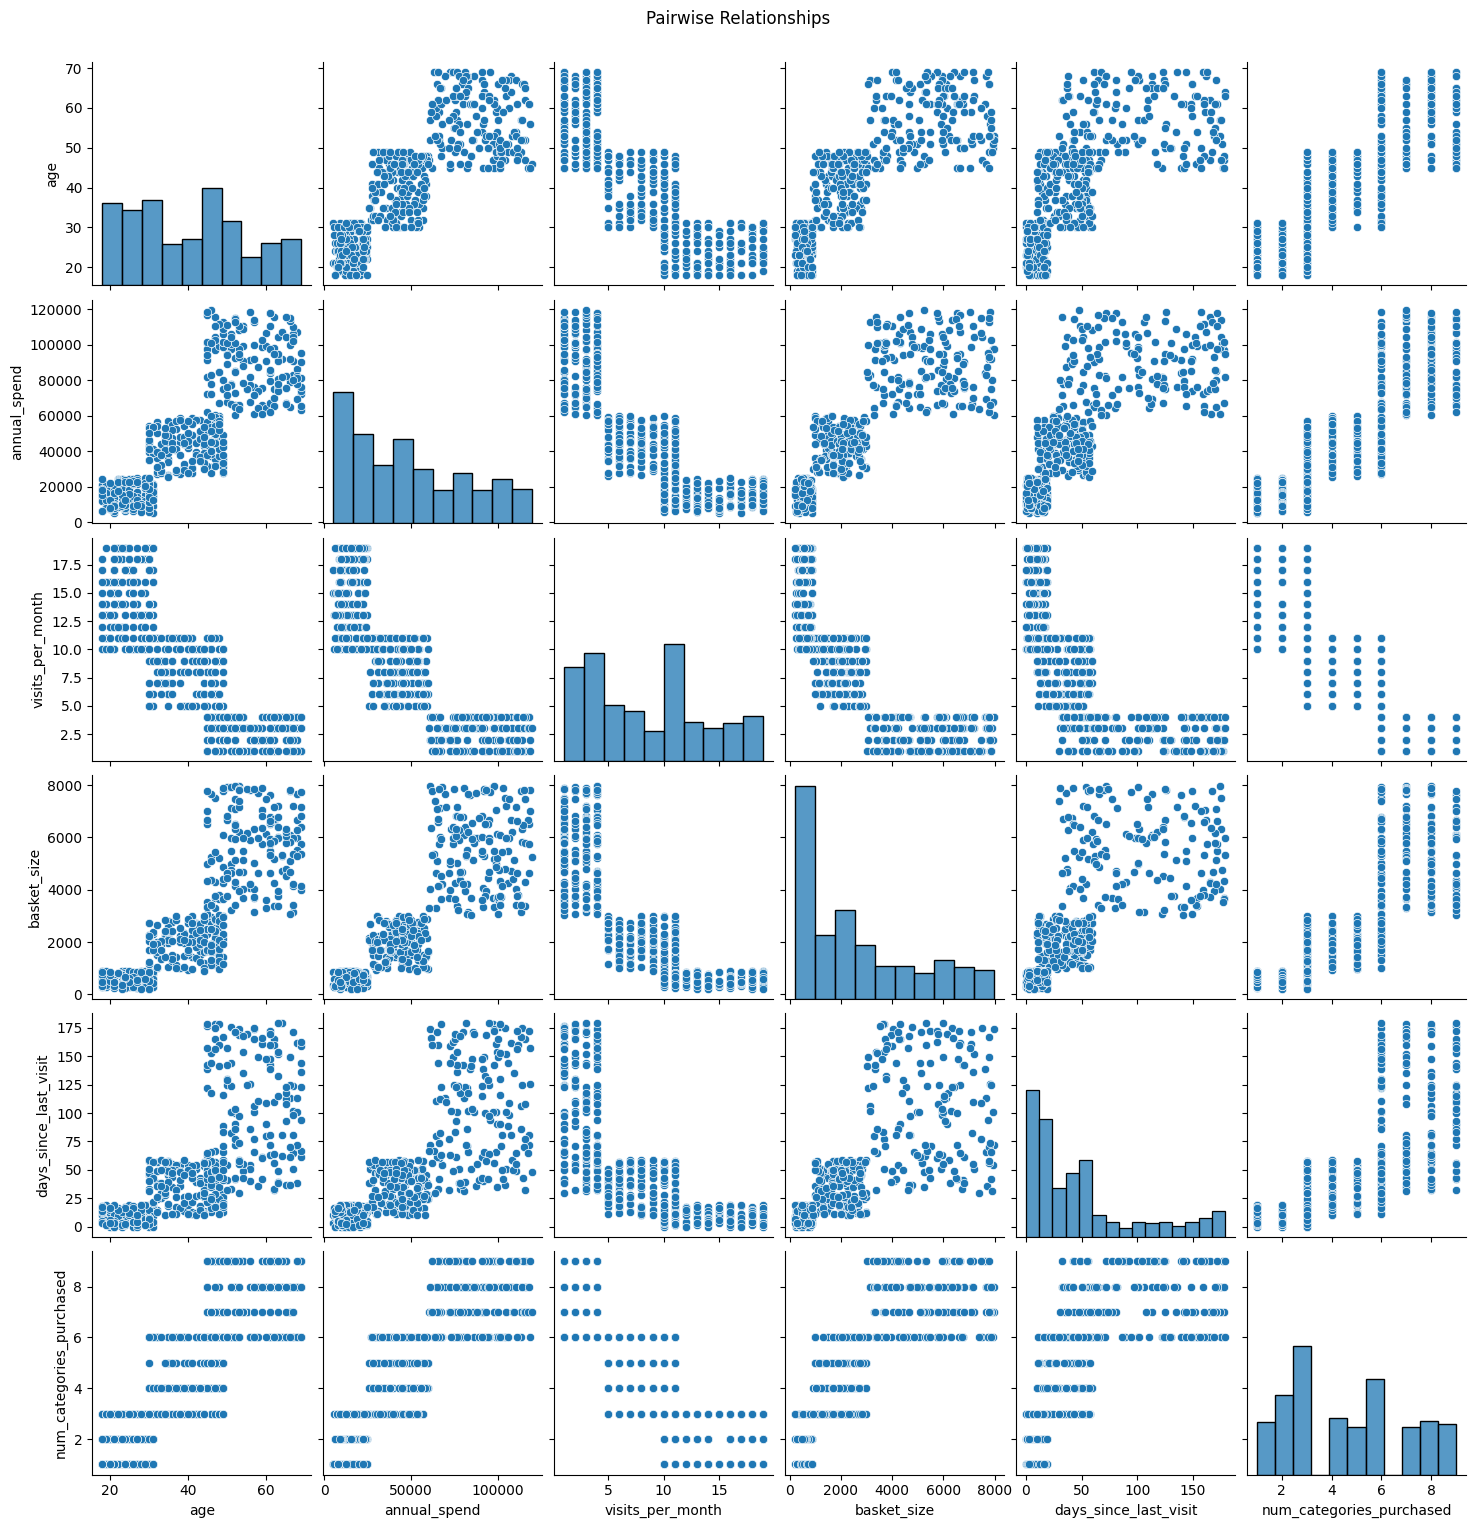

In [4]:
# Pairplot to visualize relationships
sns.pairplot(df2)
plt.suptitle('Pairwise Relationships', y=1.02)
plt.show()

## Feature Scaling

In [5]:
# Scale features before clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df2)
print('Scaled data shape:', X_scaled.shape)

Scaled data shape: (500, 6)


## KMeans Clustering and Elbow Method

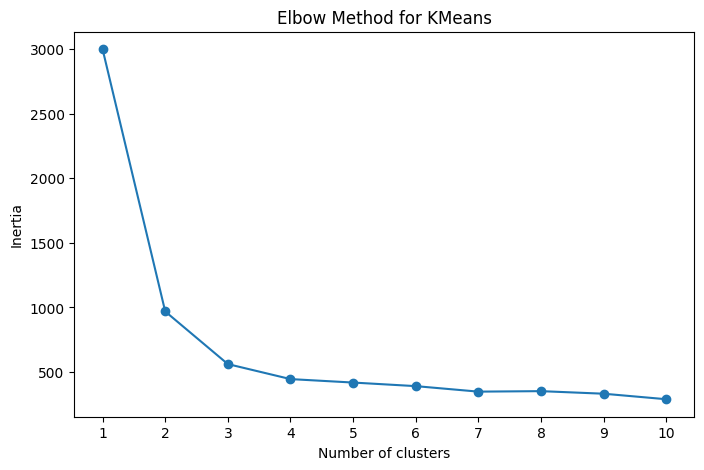

In [6]:
# Elbow method to find optimal cluster count
inertias = []
K = range(1, 11)
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
plt.figure(figsize=(8,5))
plt.plot(K, inertias, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for KMeans')
plt.xticks(K)
plt.show()

The elbow plot above suggests an appropriate number of clusters where the inertia starts to diminish slowly. Typical choices are 3 or 4.

## KMeans Clustering with chosen K

In [7]:
# Fit KMeans with K=3
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df2['Cluster'] = clusters
print('Cluster counts:')
print(df2['Cluster'].value_counts())

Cluster counts:
Cluster
0    170
2    165
1    165
Name: count, dtype: int64


In [8]:
# Silhouette score
score = silhouette_score(X_scaled, clusters)
print('Silhouette Score for K=3:', score)

Silhouette Score for K=3: 0.5081806621994936


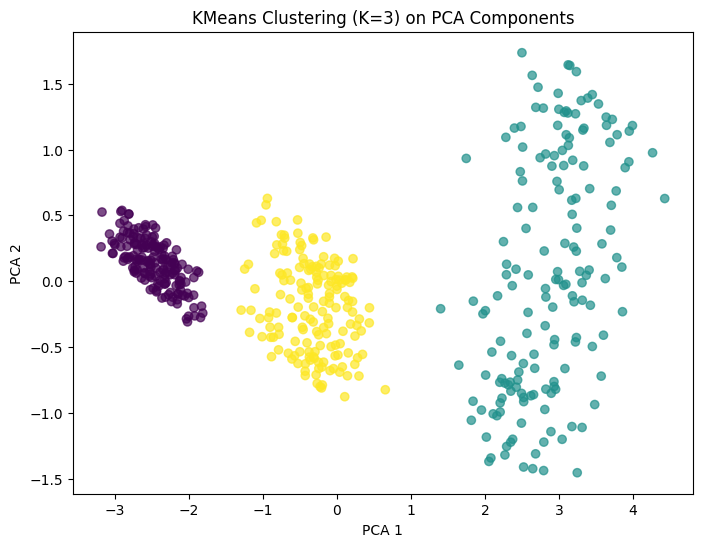

In [9]:
# Visualize clusters on first two principal components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis', alpha=0.7)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('KMeans Clustering (K=3) on PCA Components')
plt.show()